### Reducers
- By default langGraph overwrites the entire state Field with new value from each node
- So, in multi-turn conversation or mult-step agent, previous data is lost every time a node returns.

- Reducer tells langgraph to merge/append the new value with existing value instead of overwriting.
- So, all previous messages, tool results or any  accumulated data is preserved across all nodes.

#### Without Reducer: Each node's output completely replaces the state, which can lead to loss of information if not carefully managed.

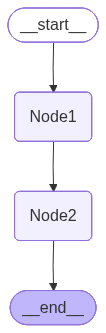

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateNoReducer(TypedDict):
    messages : list
   
def node1(state):
    print(f"Node1- current messages: {state['messages']}")   
    return {"messages": state['messages'] + ['Hello from Node1']}

def node2(state):
    print(f"Node2 - current messages: {state['messages']}")    
    return {"messages": ["How are you from Node2?"]}

# Build the graph
builder = StateGraph(StateNoReducer)
builder.add_node("Node1", node1)
builder.add_node("Node2", node2)
builder.add_edge(START, "Node1")
builder.add_edge("Node1", "Node2")
builder.add_edge("Node2", END)
graph = builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))


In [3]:
result = graph.invoke({"messages":["Hi, I am Srini"]})
print(f"Final Message: {result['messages']}")

Node1- current messages: ['Hi, I am Srini']
Node2 - current messages: ['Hi, I am Srini', 'Hello from Node1']
Final Message: ['How are you from Node2?']


#### With Reducer

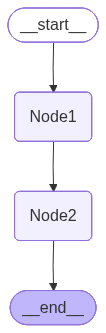

In [5]:
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END

class StateWithReducer(TypedDict):
    messages : Annotated[list,add]  # add = appends, don't overwrite entire field
   
def node1(state):
    print(f"Node1- current messages: {state['messages']}")   
    return {"messages": state['messages'] + ['Hello from Node1']}

def node2(state):
    print(f"Node2 - current messages: {state['messages']}")    
    return {"messages": ["How are you from Node2?"]}

# Build the graph
builder = StateGraph(StateWithReducer)
builder.add_node("Node1", node1)
builder.add_node("Node2", node2)
builder.add_edge(START, "Node1")
builder.add_edge("Node1", "Node2")
builder.add_edge("Node2", END)
graph = builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))


In [6]:
# Run
result = graph.invoke({"messages":["Hi, I am Srini"]})
print(f"Final Message: {result['messages']}")

Node1- current messages: ['Hi, I am Srini']
Node2 - current messages: ['Hi, I am Srini', 'Hi, I am Srini', 'Hello from Node1']
Final Message: ['Hi, I am Srini', 'Hi, I am Srini', 'Hello from Node1', 'How are you from Node2?']
